In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
distance_measure = "delta_con"
distance_name_in_csv_dict = {
    "hamming": "HammingDist", 
    "delta_con": "DeltaCon", 
    "energy": "MaxCrit"
}
distance_name_in_csv = distance_name_in_csv_dict[distance_measure]

csv_files = {
    'humans': base_dir / f"hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
    'diffusion': base_dir / f"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
    'propagation': base_dir / f"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_propagation.csv",
    'routing': base_dir / f"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_routing.csv",
    'mami': base_dir / f"suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_mami.csv"
}


In [2]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" # phylogenetic_group" # "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes
info_mami

,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,1,Mouse,Mouse,Mouse,Mus musculus,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,2,Meerkat4,Meerkat,Meerkat,Suricata suricata,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,3,CapraNubiana3,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,4,Oryx1,Oryx,Oryx,Oryx leucoryx,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,220,LemurCatta1,Ring tailed lemur,Lemur Catta,Lemur catta,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,221,FruitBat2,Egyptian fruit bat,Fruit Bat,Rousettus aegyptiacus,Rousettus,Pteropodinae,Pteropodidae,Megachiroptera,Chiroptera,Laurasiatheria,Laurasiatheria,3.4,3.28,Literature
221,222,Baboon4,Hemadryas baboon,Baboon,Papio hamadryas (Baboon),Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,223,Agouti2,Red-rumped agouti,Agouti,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


In [3]:
info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

In [4]:
df_mami = pd.read_csv(csv_files["mami"])
# drop column "DeltaCon_subject_95"
df_mami = df_mami.drop(columns=["DeltaCon_subject_95"])
df_mami

,network_index,filename,eta,gamma,id,DeltaCon_subject_0,DeltaCon_subject_1,DeltaCon_subject_2,DeltaCon_subject_3,DeltaCon_subject_4,...,DeltaCon_subject_215,DeltaCon_subject_216,DeltaCon_subject_217,DeltaCon_subject_218,DeltaCon_subject_219,DeltaCon_subject_220,DeltaCon_subject_221,DeltaCon_subject_222,DeltaCon_subject_223,DeltaCon_subject_224
0,0,net_eta1.653061270713806_gamma0.66326528787612...,1.653061,0.663265,0,9.471982,9.567229,9.531054,9.532027,10.530270,...,9.696058,9.947103,9.938538,9.826377,9.438922,10.059744,10.387988,10.507904,10.029976,9.607938
1,1,net_eta-1.040816307067872_gamma0.0346938744187...,-1.040816,0.034694,0,9.162830,8.871684,8.317440,8.598330,8.088133,...,8.198851,8.582472,8.907158,8.348844,8.250524,7.808510,8.425483,8.046019,7.859135,8.067555
2,2,net_eta-7.775510311126709_gamma-0.100000001490...,-7.775510,-0.100000,0,7.988023,7.847541,7.322078,7.766832,7.839457,...,7.586683,7.736485,7.973462,7.644672,7.372387,7.338960,7.958906,7.652986,7.294627,7.317614
3,3,net_eta-1.265306115150452_gamma0.5285714268684...,-1.265306,0.528571,0,9.061874,9.064902,8.962799,8.871732,9.162508,...,8.879109,9.077177,9.447895,9.193869,8.769544,9.207074,9.314662,9.670140,9.252783,8.880880
4,4,net_eta-4.18367338180542_gamma0.21428570151329...,-4.183673,0.214286,0,9.052549,8.810679,8.304530,8.506414,8.336364,...,8.155349,8.530859,8.697490,8.581673,8.240180,8.013021,8.668620,8.274459,8.177048,8.146424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,net_eta-3.061224460601807_gamma-0.010204084217...,-3.061224,-0.010204,9,8.444113,8.405577,7.732439,8.067641,7.857845,...,7.809782,7.984405,8.250315,7.940260,7.783149,7.606125,8.093429,7.918878,7.527986,7.772719
24996,24996,net_eta0.530612289905548_gamma0.48367348313331...,0.530612,0.483673,9,9.166017,9.078586,8.461396,8.863595,9.029455,...,8.795341,8.890124,9.213882,8.862233,8.544135,8.718861,9.201828,9.265434,8.794560,8.651443
24997,24997,net_eta1.653061270713806_gamma0.50612246990203...,1.653061,0.506122,9,8.574846,8.742491,8.552715,8.917334,9.768527,...,9.207713,8.879030,9.443869,9.196022,8.841247,9.771198,9.547515,10.202555,9.628632,9.118197
24998,24998,net_eta-2.612245082855225_gamma0.6408163309097...,-2.612245,0.640816,9,9.496558,9.487035,9.364946,9.318177,9.721195,...,9.238364,9.526038,9.834669,9.670123,9.147726,9.578863,9.944280,10.159763,9.683716,9.336433


In [5]:
df_mami = df_mami.drop(columns=["network_index", "filename"]).groupby(["eta", "gamma"]).mean().reset_index()


In [6]:
# add a column to df_mami that has the mean delta_con value in it
all_columns = [i for i in df_mami.columns if "DeltaCon_subject_" in i]
df_mami["mean_delta_con"] = df_mami[all_columns].mean(axis=1)

In [7]:
minimum_df = [] 

for col in df_mami.columns:
    # if col in ["network_index", "id", "filename", "eta", "gamma", 
    #            "Unnamed: 0", "order", "dataset"]:
    #     continue
    
    if "DeltaCon_subject_" in col:

        # Get minimum value of that column
        min_value = df_mami[col].min()
        # Save minimum value and corresponding column name
        minimum_df.append({"column": col, 
                        "min_value_individual_networks": min_value, 
                        "eta_individual_networks": df_mami.loc[df_mami[col] == min_value, "eta"].values[0],
                        "gamma_individual_networks": df_mami.loc[df_mami[col] == min_value, "gamma"].values[0],
                        # "order": df_mami.loc[df_mami[col] == min_value, "order"].values[0],
                        # "dataset": "mami"
                        })
minimum_df = pd.DataFrame(minimum_df)


# MEAN DeltaCon per network 

# # Get minimum value of that column
# min_value = df_mami["mean_delta_con"].min()
# minimum_df_mean = []
# # Save minimum value and corresponding column name
# minimum_df_mean.append({"column": col, 
#                 "min_value_mean_networks": min_value, 
#                 "eta_mean_networks": df_mami.loc[df_mami["mean_delta_con"] == min_value, "eta"].values[0],
#                 "gamma_mean_networks": df_mami.loc[df_mami["mean_delta_con"] == min_value, "gamma"].values[0],
#                 # "order": df_mami.loc[df_mami[col] == min_value, "order"].values[0],
#                 # "dataset": "mami"
#                 })
# # df_mami["mean_delta_con"] = df_mami[all_columns].mean(axis=1)

# minimum_df_mean = pd.DataFrame(minimum_df_mean)

# minimum_df = pd.concat([minimum_df, minimum_df_mean, info_mami], axis=1)
minimum_df = pd.concat([minimum_df, info_mami], axis=1)
minimum_df

,column,min_value_individual_networks,eta_individual_networks,gamma_individual_networks,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,DeltaCon_subject_0,7.502536,2.551020,0.214286,0.0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,DeltaCon_subject_1,7.637595,2.551020,0.214286,1.0,Mouse,Mouse,Mouse,Mus musculus,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,DeltaCon_subject_2,7.139872,3.000000,0.146939,2.0,Meerkat4,Meerkat,Meerkat,Suricata suricata,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,DeltaCon_subject_3,7.532684,2.551020,0.214286,3.0,CapraNubiana3,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,DeltaCon_subject_4,7.733111,-3.285714,-0.077551,4.0,Oryx1,Oryx,Oryx,Oryx leucoryx,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,DeltaCon_subject_220,7.432381,-1.040816,0.057143,220.0,LemurCatta1,Ring tailed lemur,Lemur Catta,Lemur catta,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,DeltaCon_subject_221,7.879481,-1.040816,0.057143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,DeltaCon_subject_222,7.777774,-4.632653,0.842857,222.0,Baboon4,Hemadryas baboon,Baboon,Papio hamadryas (Baboon),Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,DeltaCon_subject_223,7.327140,2.326531,0.079592,223.0,Agouti2,Red-rumped agouti,Agouti,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


In [8]:
minimum_df

,column,min_value_individual_networks,eta_individual_networks,gamma_individual_networks,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,DeltaCon_subject_0,7.502536,2.551020,0.214286,0.0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,DeltaCon_subject_1,7.637595,2.551020,0.214286,1.0,Mouse,Mouse,Mouse,Mus musculus,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,DeltaCon_subject_2,7.139872,3.000000,0.146939,2.0,Meerkat4,Meerkat,Meerkat,Suricata suricata,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,DeltaCon_subject_3,7.532684,2.551020,0.214286,3.0,CapraNubiana3,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,DeltaCon_subject_4,7.733111,-3.285714,-0.077551,4.0,Oryx1,Oryx,Oryx,Oryx leucoryx,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,DeltaCon_subject_220,7.432381,-1.040816,0.057143,220.0,LemurCatta1,Ring tailed lemur,Lemur Catta,Lemur catta,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,DeltaCon_subject_221,7.879481,-1.040816,0.057143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,DeltaCon_subject_222,7.777774,-4.632653,0.842857,222.0,Baboon4,Hemadryas baboon,Baboon,Papio hamadryas (Baboon),Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,DeltaCon_subject_223,7.327140,2.326531,0.079592,223.0,Agouti2,Red-rumped agouti,Agouti,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


In [ ]:
minimum_df = minimum_df[minimum_df[taxonomy].isin(GROUPS_TO_INCLUDE)]
print(minimum_df[taxonomy].unique())

names = minimum_df[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

['Rodentia' 'Carnivora' 'Cetartiodactyla' 'Primates']


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_7410/1994948726.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("RdYlGn_r", len(names))


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_7410/637311261.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],


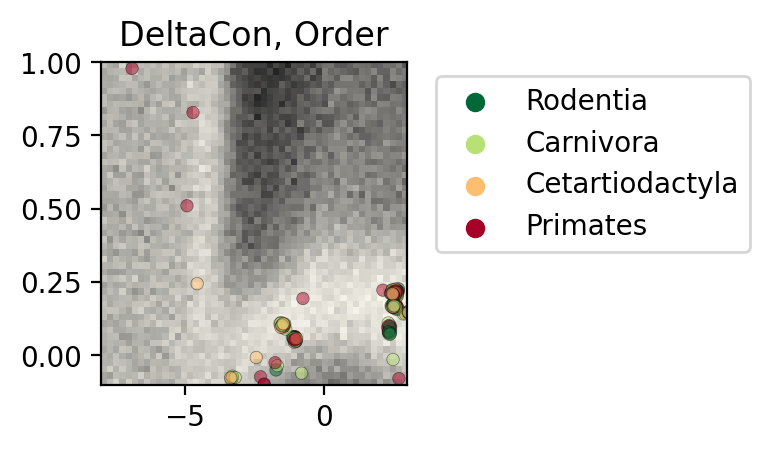

In [26]:

plt.figure(figsize=viz.cm_to_inch((10,6)), dpi=200)

# Create the heatmap
pivot_data = df_mami.pivot(index="gamma", columns="eta", values="mean_delta_con")

# Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

plt.imshow(pivot_data, 
                extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")

# Dont plot nan rows
# minimum_df = minimum_df[minimum_df["eta_individual_networks"].notna() & minimum_df["gamma_individual_networks"].notna()]

# Add slight randomness jitter in both x and y (normal dist)
jitter_strength = 0.005
plt.scatter(minimum_df["eta_individual_networks"] + np.random.normal(0, 
                                                                     jitter_strength * (x_max - x_min), 
                                                                     size=len(minimum_df)
                                                                     ),
            minimum_df["gamma_individual_networks"] + np.random.normal(0, 
                                                                       jitter_strength * (y_max - y_min), 
                                                                       size=len(minimum_df)
                                                                       ),
            color=[color_dict[i] for i in minimum_df[taxonomy]], # minimum_df["tax_color"],
            # label=df_merged_mami["order"],
            edgecolor="black",
            linewidth=0.25, 
            s=20, # 20, 
            alpha=0.5)

# if the title is too long (define this), then split it into two lines at the last underscore
# if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])

    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
for name in color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                c=color_dict[name],
                # cmap="RdYlGn_r",
                label=str(name))
    
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group
plt.title(f"DeltaCon, {taxonomy.capitalize()}")
plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_7410/3089765309.py:55: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[1].scatter([], [], c=color_dict[name], label=str(name))


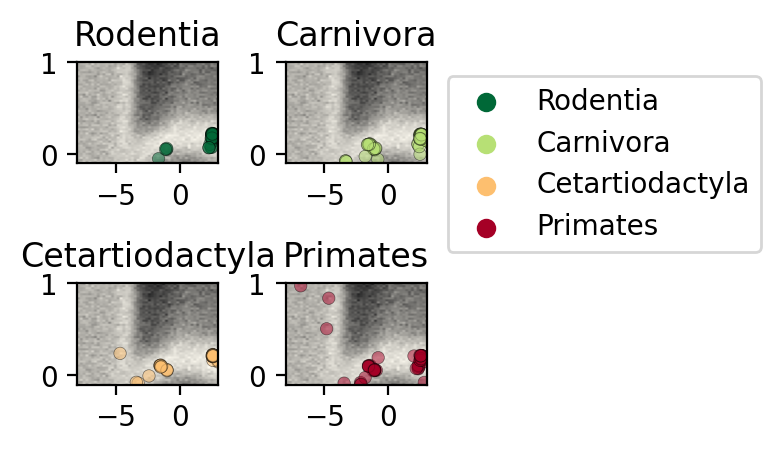

In [31]:
# Turn this into four subplots: 

fig, axs = plt.subplots(2, 2, figsize=viz.cm_to_inch((10,6)), dpi=200)
axs = axs.flatten()
# Create the heatmap
pivot_data = df_mami.pivot(index="gamma", columns="eta", values="mean_delta_con")

# Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

for i, (ax, name) in enumerate(zip(axs, names)):
    ax.imshow(pivot_data, 
                extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")

    # Add slight randomness jitter in both x and y (normal dist)
    jitter_strength = 0.005
    ax.scatter(minimum_df[minimum_df[taxonomy] == name]["eta_individual_networks"] + np.random.normal(0, 
                                                                        jitter_strength * (x_max - x_min), 
                                                                        size=len(minimum_df[minimum_df[taxonomy] == name])
                                                                        ),
                minimum_df[minimum_df[taxonomy] == name]["gamma_individual_networks"] + np.random.normal(0, 
                                                                        jitter_strength * (y_max - y_min), 
                                                                        size=len(minimum_df[minimum_df[taxonomy] == name])
                                                                        ),
                color=[color_dict[i] for i in minimum_df[minimum_df[taxonomy] == name][taxonomy]], # minimum_df["tax_color"],
                # label=df_merged_mami["order"],
                edgecolor="black",
                linewidth=0.25, 
                s=20, # 20, 
                alpha=0.5)

    ax.set_title(name)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)   
# if the title is too long (define this), then split it into two lines at the last underscore
# if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])

    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
for name in color_dict:
    # plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
    #             c=color_dict[name],
    #             # cmap="RdYlGn_r",
    #             label=str(name))
    
    axs[1].scatter([], [], c=color_dict[name], label=str(name))


axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group
# plt.title(f"DeltaCon, {taxonomy.capitalize()}")
plt.tight_layout()

In [ ]:
color_dict

{'Rodentia': (np.float64(0.0),
  np.float64(0.40784313725490196),
  np.float64(0.21568627450980393),
  np.float64(1.0)),
 'Carnivora': (np.float64(0.5254901960784315),
  np.float64(0.7960784313725491),
  np.float64(0.4019607843137255),
  np.float64(1.0)),
 'Cetartiodactyla': (np.float64(1.0),
  np.float64(1.0),
  np.float64(0.7490196078431373),
  np.float64(1.0)),
 'Primates': (np.float64(0.9745098039215687),
  np.float64(0.5549019607843138),
  np.float64(0.32156862745098036),
  np.float64(1.0)),
 nan: (np.float64(0.6470588235294118),
  np.float64(0.0),
  np.float64(0.14901960784313725),
  np.float64(1.0))}

Processing humans...
104
  Found 100 minima
Processing diffusion...
5
  Found 1 minima
Processing propagation...
5
  Found 1 minima
Processing routing...
5
  Found 1 minima
Processing mami...
229
  Found 224 minima


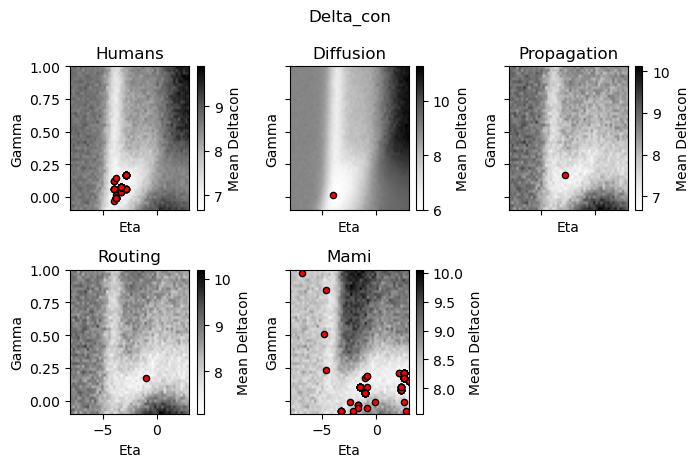

In [ ]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []
    minima_for_that_point = []
    # dataset_of_each_minimum = []
    
    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        minima_for_that_point.append(df_mean.loc[min_idx, col])
        # dataset_of_each_minimum.append(
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    # if mami, drop index 95 
    if network_name == "mami":
        minima_eta.pop(95)
        minima_gamma.pop(95)
        # dataset_of_each_minimum.pop(95)
        # number_minima.pop(95)
        
    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'minima_for_that_point': minima_for_that_point,
        'df_mean': df_mean, 
        # 'number_minima': number_minima, 
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually.
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"),
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()),
                               origin='lower', aspect='auto', cmap=cmap)  # , vmin=300, vmax=2300) # , alpha=0.5)


    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma") 
    plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', s=20, label='Minima', edgecolor='black')
    # ax_min = axs[i].scatter(minima_eta, minima_gamma, c=number_minima, s=20, label='Minima', edgecolor='black', cmap="Reds")
    # axs[i].legend()
    
    
    # Add colorbar
    # norm = plt.Normalize(df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # norm = plt.Normalize(300, 2300) # df_mean[f"{distance_name_in_csv}_mean"].min(), df_mean[f"{distance_name_in_csv}_mean"].max())
    # sm = plt.cm.ScalarMappable(cmap=cmap) # , norm=norm)
    # sm.set_array([])
    # fig.colorbar(sm, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    # plt.colorbar(ax_min, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}") # .replace(" ", "")}")
plt.tight_layout()

In [ ]:
for i in all_minima["mami"]: 
    print(len(all_minima["mami"][i]))

224
224
225
2500


In [ ]:
df_mami = pd.DataFrame(all_minima["mami"])
df_mami

ValueError: All arrays must be of the same length

In [ ]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
info_mami

,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,1,Mouse,Mouse,Mouse,Mus musculus,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,2,Meerkat4,Meerkat,Meerkat,Suricata suricata,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,3,CapraNubiana3,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,4,Oryx1,Oryx,Oryx,Oryx leucoryx,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,220,LemurCatta1,Ring tailed lemur,Lemur Catta,Lemur catta,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,221,FruitBat2,Egyptian fruit bat,Fruit Bat,Rousettus aegyptiacus,Rousettus,Pteropodinae,Pteropodidae,Megachiroptera,Chiroptera,Laurasiatheria,Laurasiatheria,3.4,3.28,Literature
221,222,Baboon4,Hemadryas baboon,Baboon,Papio hamadryas (Baboon),Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,223,Agouti2,Red-rumped agouti,Agouti,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


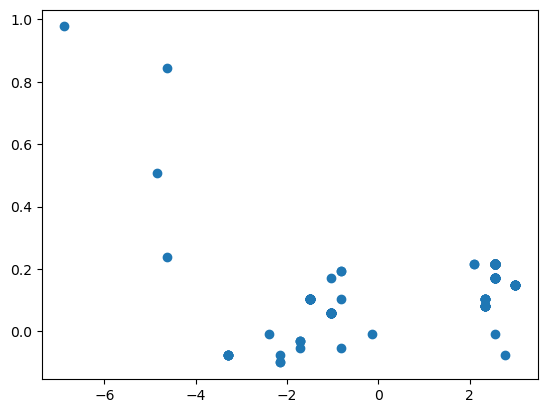

In [ ]:
plt.scatter(all_minima["mami"]["eta"], all_minima["mami"]["gamma"])

In [ ]:
df_mean

,eta,gamma,DeltaCon_subject_75,DeltaCon_subject_211,DeltaCon_subject_216,DeltaCon_subject_177,DeltaCon_subject_210,DeltaCon_subject_57,DeltaCon_subject_86,DeltaCon_subject_118,...,DeltaCon_subject_117,DeltaCon_subject_78,DeltaCon_subject_105,DeltaCon_subject_18,DeltaCon_subject_203,DeltaCon_subject_115,DeltaCon_subject_59,id,network_index,DeltaCon_mean
0,-8.0,-0.100000,8.077256,8.015041,8.622821,8.074154,8.930610,7.890558,8.422094,8.698321,...,8.507469,8.744658,8.214504,9.327188,8.357115,9.026542,8.662263,4.5,12610.0,8.544998
1,-8.0,-0.077551,8.139716,7.982232,8.644176,8.038746,8.915703,7.910975,8.439796,8.665909,...,8.539510,8.774103,8.202965,9.341463,8.276301,9.046381,8.695374,4.5,12827.0,8.552843
2,-8.0,-0.055102,7.888559,7.814175,8.441467,7.877398,8.667932,7.804141,8.223027,8.436213,...,8.288394,8.531796,8.051887,9.083122,8.152466,8.797529,8.499660,4.5,12182.7,8.354980
3,-8.0,-0.032653,7.939139,7.805613,8.486175,7.929748,8.757218,7.778890,8.290850,8.490022,...,8.363427,8.582923,8.094506,9.177342,8.176087,8.864824,8.516630,4.5,12255.0,8.400858
4,-8.0,-0.010204,7.942759,7.791453,8.518215,7.935526,8.759843,7.777891,8.257081,8.456269,...,8.343726,8.557873,8.105409,9.168634,8.196154,8.833094,8.501568,4.5,12398.4,8.381139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3.0,0.910204,8.806211,8.641882,9.422969,9.867696,8.927848,9.489351,8.783355,8.923851,...,8.958604,8.911818,10.296859,9.013686,9.866120,9.048072,9.065105,4.5,12582.1,9.263788
2496,3.0,0.932653,8.812780,8.720059,9.493238,9.931485,8.993369,9.540033,8.816584,8.996121,...,8.918842,8.995114,10.351753,9.098262,9.942977,9.066011,9.133497,4.5,12770.8,9.326254
2497,3.0,0.955102,8.602320,8.486341,9.207567,9.600382,8.770674,9.218619,8.593588,8.710676,...,8.717570,8.721675,9.960290,8.835038,9.513437,8.838719,8.878363,4.5,12568.7,9.053631
2498,3.0,0.977551,8.464687,8.481102,9.196702,9.677981,8.716055,9.196829,8.516046,8.675533,...,8.666760,8.685849,10.092501,8.806593,9.642574,8.739122,8.806322,4.5,12389.1,9.032816


In [ ]:
df_mean.loc[min_idx]

eta                         2.551020
gamma                       0.214286
DeltaCon_subject_75         7.129181
DeltaCon_subject_211        7.155134
DeltaCon_subject_216        7.734184
                            ...     
DeltaCon_subject_115        7.468379
DeltaCon_subject_59         7.338575
id                          4.500000
network_index           12242.800000
DeltaCon_mean               7.561851
Name: 2364, Length: 230, dtype: float64

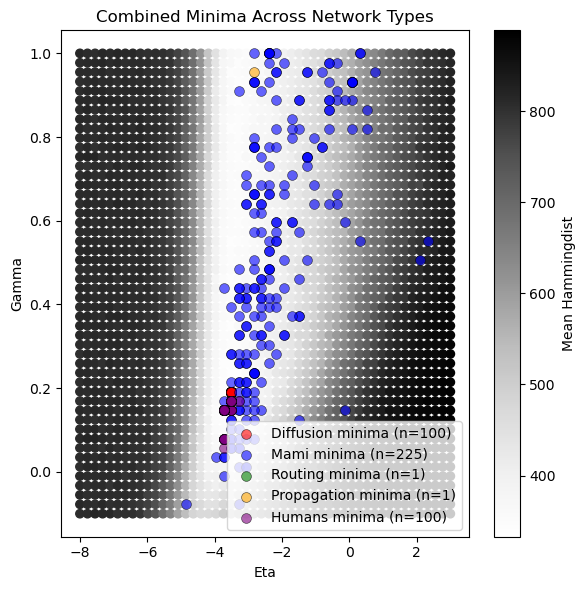


SUMMARY STATISTICS

DIFFUSION:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.192, 0.192]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.192 ± 0.000

MAMI:
  Eta range: [-4.857, 2.327]
  Gamma range: [-0.078, 1.000]
  Eta mean ± std: -2.231 ± 1.175
  Gamma mean ± std: 0.525 ± 0.304

ROUTING:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

PROPAGATION:
  Eta range: [-2.837, -2.837]
  Gamma range: [0.955, 0.955]
  Eta mean ± std: -2.837 ± 0.000
  Gamma mean ± std: 0.955 ± 0.000

HUMANS:
  Eta range: [-3.735, -3.286]
  Gamma range: [0.057, 0.169]
  Eta mean ± std: -3.665 ± 0.109
  Gamma mean ± std: 0.146 ± 0.024


In [ ]:

# Create the combined plot
plt.figure(figsize=(6,6), dpi=100)

# Define colors for each network type
colors = {
    'diffusion': 'red',
    'mami': 'blue',
    'routing': 'green', 
    'propagation': 'orange',
    'humans': 'purple'
}

cmap = "Grays"

# Plot the landscape from one network (they should be similar)
# Using diffusion as the base
base_network = 'diffusion'
df_mean = all_minima[base_network]['df_mean']
if f"{distance_name_in_csv}_mean" not in df_mean.columns:
    # Calculate mean across all subjects
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean[f"{distance_name_in_csv}_mean"], 
            cmap=cmap) # , # alpha=0.3, s=30, label='Landscape (mean DeltaCon)')

# Add colorbar for the landscape
plt.colorbar(label=f'Mean {distance_name_in_csv.capitalize()}')

# Plot minima for each network type
for network_name, color in colors.items():
    minima = all_minima[network_name]
    plt.scatter(minima['eta'], minima['gamma'], 
                c=color, marker='o', s=50, alpha=0.6, 
                label=f'{network_name.capitalize()} minima (n={len(minima["eta"])})',
                edgecolors='black', linewidths=0.5)

plt.xlabel('Eta')
plt.ylabel('Gamma') 
plt.title('Combined Minima Across Network Types') 
plt.legend(loc='best')
plt.tight_layout()

# Save the figure
output_path = "/home/claude/combined_minima_plot.png"
# plt.savefig(output_path, dpi=150, bbox_inches='tight')
# print(f"\nPlot saved to: {output_path}")
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for network_name in colors.keys():
    minima = all_minima[network_name]
    print(f"\n{network_name.upper()}:")
    print(f"  Eta range: [{np.min(minima['eta']):.3f}, {np.max(minima['eta']):.3f}]")
    print(f"  Gamma range: [{np.min(minima['gamma']):.3f}, {np.max(minima['gamma']):.3f}]")
    print(f"  Eta mean ± std: {np.mean(minima['eta']):.3f} ± {np.std(minima['eta']):.3f}")
    print(f"  Gamma mean ± std: {np.mean(minima['gamma']):.3f} ± {np.std(minima['gamma']):.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_35412/2709138288.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,


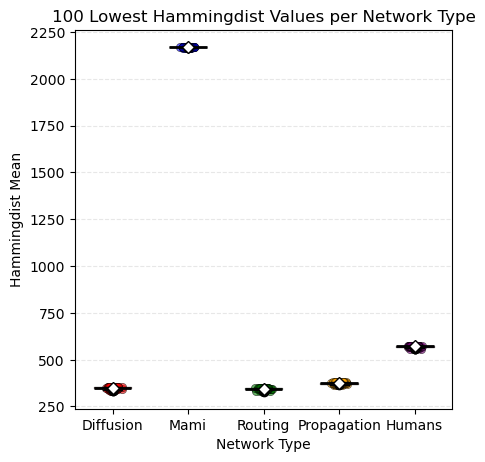


SUMMARY STATISTICS (100 LOWEST VALUES)

DIFFUSION:
  Min: 332.800000
  Q1 (25th percentile): 347.150000
  Median: 350.200000
  Q3 (75th percentile): 353.200000
  Max: 355.600000
  Mean ± std: 349.418000 ± 4.979646

MAMI:
  Min: 2164.302222
  Q1 (25th percentile): 2167.221111
  Median: 2167.773333
  Q3 (75th percentile): 2168.320444
  Max: 2168.744889
  Mean ± std: 2167.701342 ± 0.803474

ROUTING:
  Min: 329.600000
  Q1 (25th percentile): 341.600000
  Median: 344.900000
  Q3 (75th percentile): 347.600000
  Max: 349.800000
  Mean ± std: 343.832000 ± 4.593885

PROPAGATION:
  Min: 362.000000
  Q1 (25th percentile): 371.050000
  Median: 373.900000
  Q3 (75th percentile): 376.650000
  Max: 379.400000
  Mean ± std: 373.490000 ± 3.861023

HUMANS:
  Min: 554.556000
  Q1 (25th percentile): 568.038000
  Median: 570.835000
  Q3 (75th percentile): 573.237000
  Max: 574.978000
  Mean ± std: 569.955420 ± 4.224110


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

colors_list = ['red', 'blue', 'green', 'orange', 'purple']
network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[distance_measure_columns].mean(axis=1)

    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(network_name.capitalize())

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=100)

bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=False,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='white', 
                              markeredgecolor='black', markersize=6))

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], alpha=0.6, edgecolor='black', linewidth=0.5)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
ax.set_xlabel('Network Type')
ax.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(network_types):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")